# CCC Column Charts with 95% CI

This notebook reads CCC outputs from `data/ccc` and creates side-by-side column charts (flexion and extension) with CI whiskers.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

figure_colors = {
    "OMC": "black",
    "RTMW: Performance": "#3ec5ef",
    "HSMR": "#ff886b",
    "SOC": "#a274d4",
}

method_order = ['rtmw', 'hsmr', 'soc']
method_labels = ['RTMW', 'HSMR', 'SOC']
method_colors = [
    figure_colors['RTMW: Performance'],
    figure_colors['HSMR'],
    figure_colors['SOC']
]

In [21]:
project_root = Path.cwd()
if (project_root / 'data' / 'ccc').exists():
    pass
elif (project_root.parent / 'data' / 'ccc').exists():
    project_root = project_root.parent
else:
    raise FileNotFoundError('Could not find data/ccc from current working directory.')

ccc_dir = project_root / 'data' / 'ccc'
out_dir = project_root / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

ccc_files = sorted(ccc_dir.glob('ccc_*_*.csv'))
if not ccc_files:
    raise FileNotFoundError(f'No CCC CSV files found in: {ccc_dir}')

ccc_df = pd.concat([pd.read_csv(path) for path in ccc_files], ignore_index=True)
ccc_df[['method', 'motion', 'ccc', 'lower', 'upper']].head()

,method,motion,ccc,lower,upper
0,hsmr,extension,0.717172,0.568141,0.797701
1,hsmr,flexion,0.924846,0.661423,0.969257
2,rtmw,extension,0.828660,0.744942,0.895731
3,rtmw,flexion,0.798018,0.443272,0.911175
4,soc,extension,0.861092,0.758794,0.913892


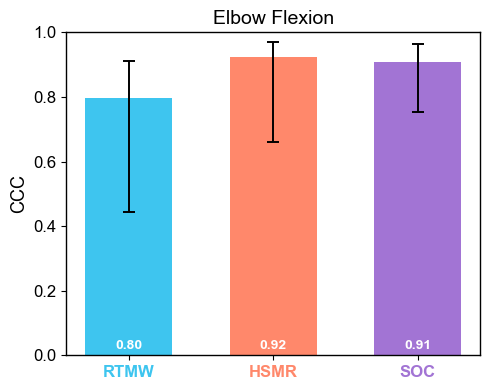

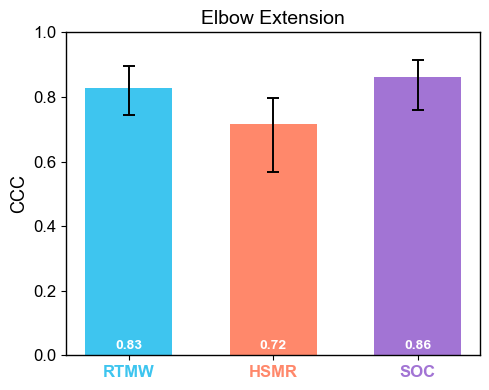

In [22]:
def plot_ccc_motion(motion, title, out_stem):
    subset = (
        ccc_df[ccc_df['motion'] == motion]
        .set_index('method')
        .reindex(method_order)
        .reset_index()
    )

    x = np.arange(len(method_order))
    y = subset['ccc'].to_numpy()
    yerr_lower = y - subset['lower'].to_numpy()
    yerr_upper = subset['upper'].to_numpy() - y

    fig, ax = plt.subplots(1, 1, figsize=(5, 4))

    ax.bar(x, y, color=method_colors, width=0.6, zorder=2)
    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt='none',
        ecolor='black',
        elinewidth=1.4,
        capsize=4,
        capthick=1.4,
        zorder=3
    )

    for i, val in enumerate(y):
        ax.text(i, 0.01, f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

    ax.set_title(title, fontsize=14)
    ax.set_ylabel('CCC', fontsize=13)
    ax.set_xlabel('')
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    for tick, color in zip(ax.get_xticklabels(), method_colors):
        tick.set_color(color)

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(out_dir / f'{out_stem}.pdf', bbox_inches='tight')
    plt.show()

plot_ccc_motion('flexion', 'Elbow Flexion', '02_ccc_flexion')
plot_ccc_motion('extension', 'Elbow Extension', '02_ccc_extension')